# **project:Heart Disease Risk**
> the system takes basic health related input from user.
>uses machine learning model trained data to predict whether the person falls into low risk or higher riskcategory.
>uses KNN and NAVIE BAYES ml model.
<img src="https://miro.medium.com/v2/resize:fit:1172/1*-FFd0FOJxwFIrxj-A1lPBA.jpeg">

In [47]:
## importing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib

In [2]:
df = pd.read_csv("/content/heart_disease_risk_dataset_earlymed.csv")

In [3]:
print(df.head())

   Chest_Pain  Shortness_of_Breath  Fatigue  Palpitations  Dizziness  \
0         0.0                  0.0      0.0           1.0        0.0   
1         0.0                  1.0      0.0           1.0        0.0   
2         1.0                  0.0      0.0           1.0        0.0   
3         1.0                  1.0      0.0           1.0        0.0   
4         0.0                  0.0      1.0           0.0        1.0   

   Swelling  Pain_Arms_Jaw_Back  Cold_Sweats_Nausea  High_BP  \
0       0.0                 0.0                 0.0      0.0   
1       0.0                 0.0                 0.0      1.0   
2       0.0                 0.0                 0.0      1.0   
3       0.0                 1.0                 1.0      1.0   
4       0.0                 0.0                 0.0      0.0   

   High_Cholesterol  Diabetes  Smoking  Obesity  Sedentary_Lifestyle  \
0               0.0       0.0      1.0      0.0                  1.0   
1               0.0       0.0      1.0

In [5]:
df.columns

Index(['Chest_Pain', 'Shortness_of_Breath', 'Fatigue', 'Palpitations',
       'Dizziness', 'Swelling', 'Pain_Arms_Jaw_Back', 'Cold_Sweats_Nausea',
       'High_BP', 'High_Cholesterol', 'Diabetes', 'Smoking', 'Obesity',
       'Sedentary_Lifestyle', 'Family_History', 'Chronic_Stress', 'Gender',
       'Age', 'Heart_Risk'],
      dtype='object')

In [6]:
# Convert categorical columns into numbers
for column in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column].astype(str))

In [13]:
print(df.shape)

(70000, 19)


In [14]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Chest_Pain           70000 non-null  float64
 1   Shortness_of_Breath  70000 non-null  float64
 2   Fatigue              70000 non-null  float64
 3   Palpitations         70000 non-null  float64
 4   Dizziness            70000 non-null  float64
 5   Swelling             70000 non-null  float64
 6   Pain_Arms_Jaw_Back   70000 non-null  float64
 7   Cold_Sweats_Nausea   70000 non-null  float64
 8   High_BP              70000 non-null  float64
 9   High_Cholesterol     70000 non-null  float64
 10  Diabetes             70000 non-null  float64
 11  Smoking              70000 non-null  float64
 12  Obesity              70000 non-null  float64
 13  Sedentary_Lifestyle  70000 non-null  float64
 14  Family_History       70000 non-null  float64
 15  Chronic_Stress       70000 non-null 

In [15]:
print(df.isnull().sum())


Chest_Pain             0
Shortness_of_Breath    0
Fatigue                0
Palpitations           0
Dizziness              0
Swelling               0
Pain_Arms_Jaw_Back     0
Cold_Sweats_Nausea     0
High_BP                0
High_Cholesterol       0
Diabetes               0
Smoking                0
Obesity                0
Sedentary_Lifestyle    0
Family_History         0
Chronic_Stress         0
Gender                 0
Age                    0
Heart_Risk             0
dtype: int64


In [9]:
X = df.drop('Heart_Risk', axis=1)

In [16]:
y = df['Heart_Risk']


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
model = RandomForestClassifier(random_state=42)

In [21]:
##training the model
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [22]:
y_pred = model.predict(X_test)
print(y_pred[:20])


[0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 1. 1. 0. 0. 1. 0. 1. 0. 1.]


In [23]:
accuracy = accuracy_score(y_test, y_pred)

In [32]:
# Precision
precision = precision_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)


In [35]:
# Recall
recall = recall_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)


In [38]:
# F1 Score
f1 = f1_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)


In [39]:
print("\n============================================")
print("           MODEL EVALUATION")
print("============================================")

print("Accuracy  :", round(accuracy * 100, 2), "%")
print("Precision :", round(precision * 100, 2), "%")
print("Recall    :", round(recall * 100, 2), "%")
print("F1 Score  :", round(f1 * 100, 2), "%")



           MODEL EVALUATION
Accuracy  : 99.21 %
Precision : 99.21 %
Recall    : 99.21 %
F1 Score  : 99.21 %


In [40]:
cm = confusion_matrix(y_test, y_pred)


In [42]:
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))


Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      6998
         1.0       0.99      0.99      0.99      7002

    accuracy                           0.99     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000



In [43]:


feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

In [44]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [46]:
print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
                Feature  Importance
17                  Age    0.142637
7    Cold_Sweats_Nausea    0.116433
2               Fatigue    0.114737
4             Dizziness    0.095555
1   Shortness_of_Breath    0.094599
6    Pain_Arms_Jaw_Back    0.094076
5              Swelling    0.093624
0            Chest_Pain    0.090013
3          Palpitations    0.072287
13  Sedentary_Lifestyle    0.012144
8               High_BP    0.010817
12              Obesity    0.010355
9      High_Cholesterol    0.010267
15       Chronic_Stress    0.010112
14       Family_History    0.009458
11              Smoking    0.009421
10             Diabetes    0.008761
16               Gender    0.004705


### 3. Data Preprocessing (using Pipeline and ColumnTransformer)

This section focuses on preparing the data for machine learning models. We will identify numerical and categorical features, handle potential outliers, and apply appropriate scaling techniques using `ColumnTransformer` to ensure our models perform optimally.

In [48]:
# Identify numerical and binary features
# Based on df.info() and df.head(), 'Age' is a continuous numerical feature.
# All other features are binary (0.0 or 1.0) and do not necessarily need scaling,
# but we will define them to be passed through the ColumnTransformer.

numerical_features = ['Age']
binary_features = [col for col in X.columns if col not in numerical_features]

# Create a ColumnTransformer for preprocessing
# Standardize numerical features and pass through binary features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('bin', 'passthrough', binary_features)
    ],
    remainder='passthrough'
)

print(f"Numerical Features to be scaled: {numerical_features}")
print(f"Binary Features to be passed through: {binary_features}")

Numerical Features to be scaled: ['Age']
Binary Features to be passed through: ['Chest_Pain', 'Shortness_of_Breath', 'Fatigue', 'Palpitations', 'Dizziness', 'Swelling', 'Pain_Arms_Jaw_Back', 'Cold_Sweats_Nausea', 'High_BP', 'High_Cholesterol', 'Diabetes', 'Smoking', 'Obesity', 'Sedentary_Lifestyle', 'Family_History', 'Chronic_Stress', 'Gender']


In [49]:
# Apply the preprocessor to the training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get the feature names after preprocessing
# The ColumnTransformer returns a NumPy array, so we need to reconstruct DataFrame for better interpretability
# This also helps in visualizing feature importances for models that don't directly handle pipelines

# Get feature names from numerical transformer
numerical_feature_names = numerical_features
# Get feature names from passthrough transformer (binary features)
binary_feature_names = binary_features

# Combine all feature names in the correct order
processed_feature_names = numerical_feature_names + binary_feature_names

X_train_processed = pd.DataFrame(X_train_processed, columns=processed_feature_names, index=X_train.index)
X_test_processed = pd.DataFrame(X_test_processed, columns=processed_feature_names, index=X_test.index)

print("Shape of X_train_processed:", X_train_processed.shape)
print("Shape of X_test_processed:", X_test_processed.shape)
print("\nFirst 5 rows of X_train_processed:")
print(X_train_processed.head())

Shape of X_train_processed: (56000, 18)
Shape of X_test_processed: (14000, 18)

First 5 rows of X_train_processed:
            Age  Chest_Pain  Shortness_of_Breath  Fatigue  Palpitations  \
47339  0.216516         1.0                  1.0      1.0           1.0   
67456  1.192331         1.0                  1.0      1.0           0.0   
12308 -0.454356         1.0                  1.0      0.0           1.0   
32557 -1.491159         0.0                  1.0      0.0           0.0   
664   -1.796101         0.0                  0.0      0.0           0.0   

       Dizziness  Swelling  Pain_Arms_Jaw_Back  Cold_Sweats_Nausea  High_BP  \
47339        0.0       1.0                 1.0                 1.0      0.0   
67456        1.0       1.0                 1.0                 1.0      1.0   
12308        1.0       1.0                 0.0                 0.0      0.0   
32557        0.0       0.0                 0.0                 0.0      0.0   
664          0.0       1.0             

### 4. Model Training and Evaluation

In this section, we will train three different machine learning models: Logistic Regression, Decision Tree Classifier, and Random Forest Classifier. For each model, we will train it on the preprocessed training data (`X_train_processed`, `y_train`), make predictions on the preprocessed test data (`X_test_processed`), and then evaluate its performance using various metrics.

#### 4.1 Logistic Regression

In [50]:
# Initialize and train the Logistic Regression model
logistic_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver recommended for small datasets or L1/L2 regularization
logistic_model.fit(X_train_processed, y_train)

# Make predictions on the processed test data
y_pred_logistic = logistic_model.predict(X_test_processed)

# Evaluate the Logistic Regression model
print("Logistic Regression Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_logistic):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_logistic, average='weighted', zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_logistic, average='weighted', zero_division=0):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_logistic, average='weighted', zero_division=0):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_logistic))
print("\nClassification Report:\n", classification_report(y_test, y_pred_logistic, zero_division=0))

Logistic Regression Model Evaluation:
Accuracy: 0.9916
Precision: 0.9916
Recall: 0.9916
F1 Score: 0.9916

Confusion Matrix:
 [[6936   62]
 [  56 6946]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      6998
         1.0       0.99      0.99      0.99      7002

    accuracy                           0.99     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000



#### 4.2 Decision Tree Classifier

In [51]:
# Initialize and train the Decision Tree Classifier model
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train_processed, y_train)

# Make predictions on the processed test data
y_pred_decision_tree = decision_tree_model.predict(X_test_processed)

# Evaluate the Decision Tree Classifier model
print("Decision Tree Classifier Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_decision_tree):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_decision_tree, average='weighted', zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_decision_tree, average='weighted', zero_division=0):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_decision_tree, average='weighted', zero_division=0):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_decision_tree))
print("\nClassification Report:\n", classification_report(y_test, y_pred_decision_tree, zero_division=0))

Decision Tree Classifier Model Evaluation:
Accuracy: 0.9804
Precision: 0.9804
Recall: 0.9804
F1 Score: 0.9804

Confusion Matrix:
 [[6865  133]
 [ 141 6861]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      6998
         1.0       0.98      0.98      0.98      7002

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



#### 4.3 Random Forest Classifier

In [52]:
# Initialize and train the Random Forest Classifier model
# We're re-initializing this to ensure it uses the preprocessed data
random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train_processed, y_train)

# Make predictions on the processed test data
y_pred_random_forest = random_forest_model.predict(X_test_processed)

# Evaluate the Random Forest Classifier model
print("Random Forest Classifier Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_random_forest):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_random_forest, average='weighted', zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_random_forest, average='weighted', zero_division=0):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_random_forest, average='weighted', zero_division=0):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_random_forest))
print("\nClassification Report:\n", classification_report(y_test, y_pred_random_forest, zero_division=0))

# Update and print feature importance for the re-trained Random Forest model
feature_importance_rf = pd.DataFrame({
    "Feature": processed_feature_names,
    "Importance": random_forest_model.feature_importances_
})
feature_importance_rf = feature_importance_rf.sort_values(by="Importance", ascending=False)

print("\nFeature Importance (Random Forest - with processed features):\n", feature_importance_rf)

Random Forest Classifier Model Evaluation:
Accuracy: 0.9915
Precision: 0.9915
Recall: 0.9915
F1 Score: 0.9915

Confusion Matrix:
 [[6938   60]
 [  59 6943]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      6998
         1.0       0.99      0.99      0.99      7002

    accuracy                           0.99     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000


Feature Importance (Random Forest - with processed features):
                 Feature  Importance
0                   Age    0.143313
7    Pain_Arms_Jaw_Back    0.110972
8    Cold_Sweats_Nausea    0.110236
2   Shortness_of_Breath    0.103580
5             Dizziness    0.100002
6              Swelling    0.095044
1            Chest_Pain    0.089096
3               Fatigue    0.086667
4          Palpitations    0.077268
9               High_BP    0.011407
14  Sedentary_Lifestyle    0.01

### 5. Model Comparison and Selection

To determine the best-performing model, we will create a comparison table summarizing the key evaluation metrics for Logistic Regression, Decision Tree, and Random Forest Classifiers.

In [53]:
# Store metrics for comparison
metrics = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_decision_tree),
        accuracy_score(y_test, y_pred_random_forest)
    ],
    'Precision': [
        precision_score(y_test, y_pred_logistic, average='weighted', zero_division=0),
        precision_score(y_test, y_pred_decision_tree, average='weighted', zero_division=0),
        precision_score(y_test, y_pred_random_forest, average='weighted', zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_pred_logistic, average='weighted', zero_division=0),
        recall_score(y_test, y_pred_decision_tree, average='weighted', zero_division=0),
        recall_score(y_test, y_pred_random_forest, average='weighted', zero_division=0)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_logistic, average='weighted', zero_division=0),
        f1_score(y_test, y_pred_decision_tree, average='weighted', zero_division=0),
        f1_score(y_test, y_pred_random_forest, average='weighted', zero_division=0)
    ]
}

metrics_df = pd.DataFrame(metrics)
print("\nModel Comparison Table:")
print(metrics_df.round(4))

# Identify the best model based on Accuracy (or F1-score for imbalanced datasets)
best_model_row = metrics_df.loc[metrics_df['Accuracy'].idxmax()]
best_model_name = best_model_row['Model']
best_model_accuracy = best_model_row['Accuracy']

print(f"\nBased on accuracy, the best performing model is: {best_model_name} with an Accuracy of {best_model_accuracy:.4f}")


Model Comparison Table:
                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.9916     0.9916  0.9916    0.9916
1        Decision Tree    0.9804     0.9804  0.9804    0.9804
2        Random Forest    0.9915     0.9915  0.9915    0.9915

Based on accuracy, the best performing model is: Logistic Regression with an Accuracy of 0.9916


### 6. Visualizing Model Performance

Visualizing the model's performance helps in understanding how well each model categorizes the heart risk. We will generate confusion matrices for each model, an accuracy comparison plot, and a feature importance plot for the Random Forest model.

#### 6.1 Confusion Matrices

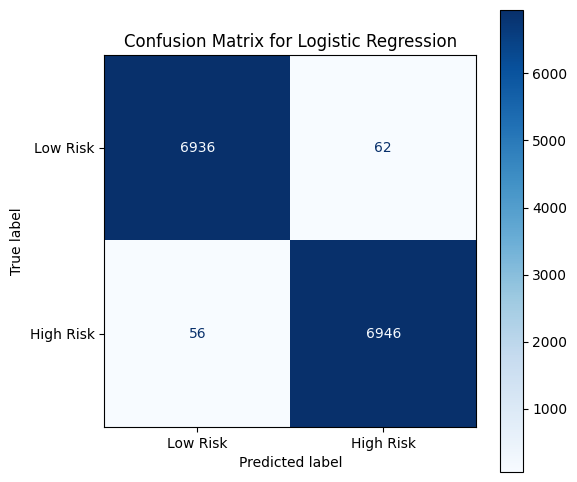

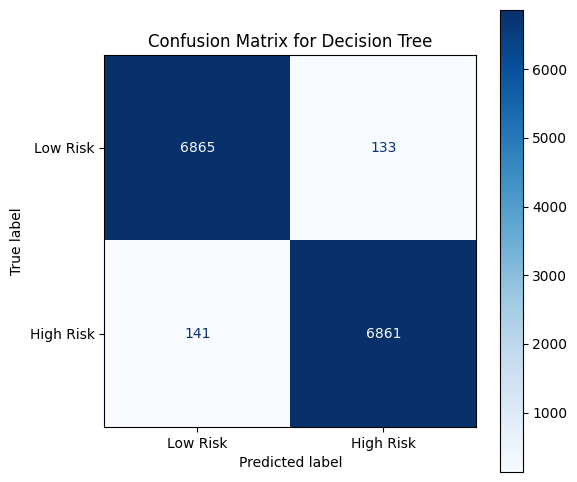

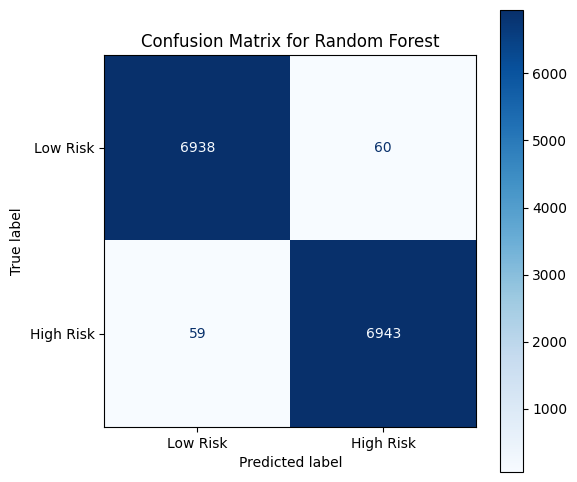

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Risk', 'High Risk'])
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix for {model_name}')
    plt.show()

# Plot confusion matrix for Logistic Regression
plot_confusion_matrix(y_test, y_pred_logistic, 'Logistic Regression')

# Plot confusion matrix for Decision Tree
plot_confusion_matrix(y_test, y_pred_decision_tree, 'Decision Tree')

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, y_pred_random_forest, 'Random Forest')

#### 6.2 Model Accuracy Comparison Plot

/tmp/ipykernel_1275/2306361810.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=metrics_df, palette='viridis')


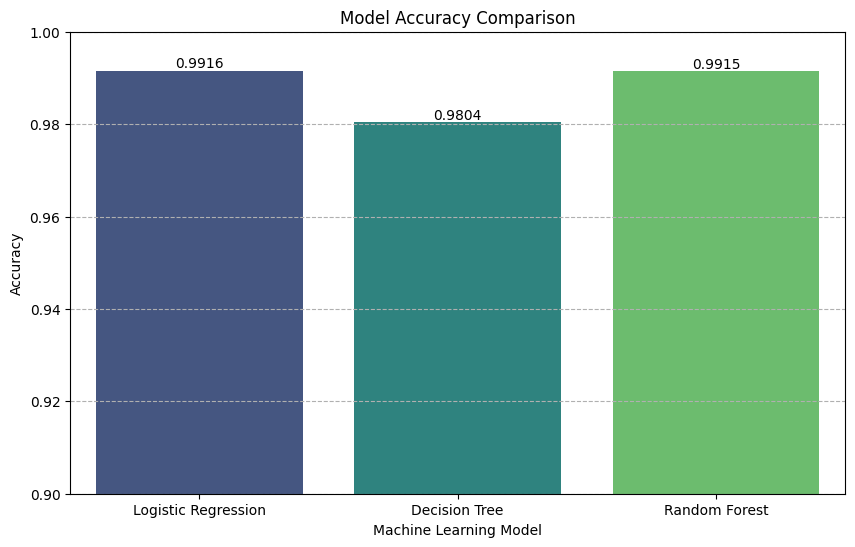

In [55]:
# Create a bar plot for model accuracy comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=metrics_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Machine Learning Model')
plt.ylabel('Accuracy')
plt.ylim(0.9, 1.0) # Set y-axis limits to focus on the differences

# Add accuracy values on top of the bars
for index, row in metrics_df.iterrows():
    plt.text(index, row.Accuracy, f'{row.Accuracy:.4f}', color='black', ha="center", va="bottom")

plt.grid(axis='y', linestyle='--')
plt.show()

#### 6.3 Feature Importance Plot (Random Forest)

/tmp/ipykernel_1275/2440321867.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_rf, palette='magma')


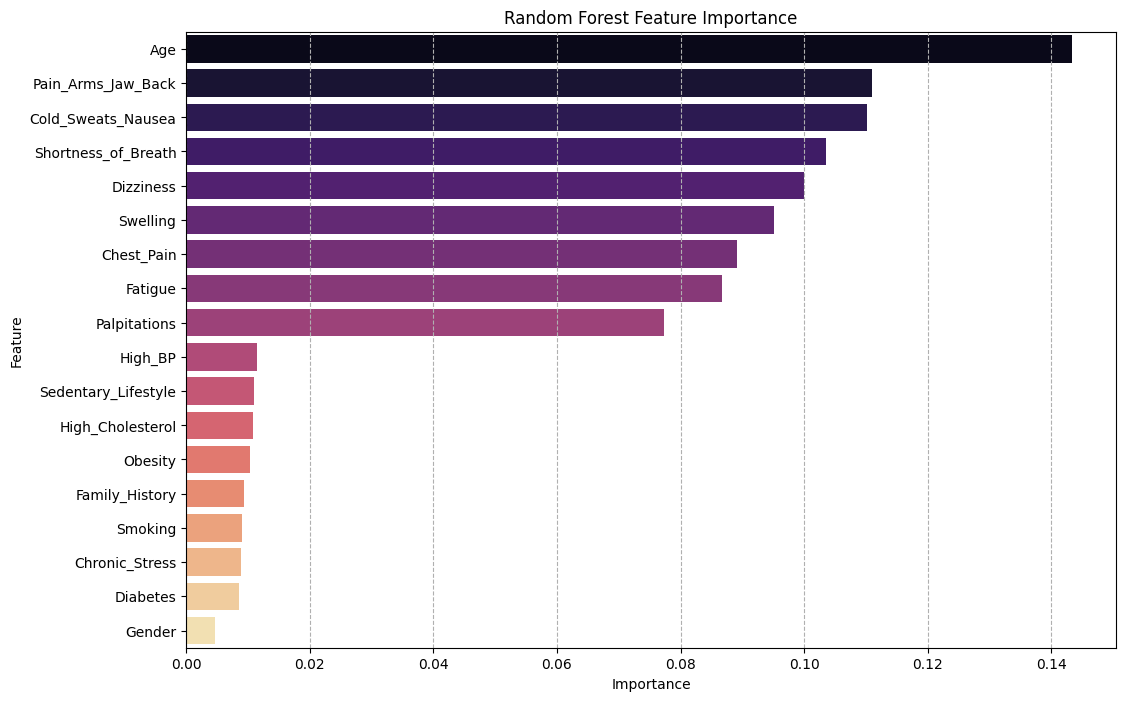

In [56]:
# Plotting feature importance for Random Forest
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_rf, palette='magma')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--')
plt.show()

### 7. Saving and Loading the Best Model

To ensure our best-performing model can be used without retraining, we will save it to disk. We will then demonstrate how to load the model back into memory.

#### 7.1 Saving the Best Model

In [57]:
# Identify the best model based on previous comparison (Logistic Regression)
best_model = logistic_model # Based on 'Model Comparison Table' where Logistic Regression had highest accuracy

# Define a filename for the saved model
model_filename = 'logistic_regression_heart_risk_model.joblib'

# Save the model
joblib.dump(best_model, model_filename)

print(f"Best model (Logistic Regression) saved as '{model_filename}'")

Best model (Logistic Regression) saved as 'logistic_regression_heart_risk_model.joblib'


#### 7.2 Loading the Saved Model

In [58]:
# Load the model from disk
loaded_model = joblib.load(model_filename)

print(f"Model '{model_filename}' loaded successfully.")

Model 'logistic_regression_heart_risk_model.joblib' loaded successfully.


### 8. Making a Sample Prediction

Now that we have our best model saved and loaded, let's demonstrate how to use it to predict heart disease risk for a new, unseen individual. We'll create a hypothetical patient profile, preprocess it using the same `preprocessor` fitted on our training data, and then get a prediction.

In [59]:
# Create a sample new patient data (using the original feature names)
# This dictionary should mimic the structure of a single row in your original X DataFrame
# Make sure to include all 18 features in the correct order or by name.

sample_patient_data = {
    'Chest_Pain': [1.0],  # Yes
    'Shortness_of_Breath': [1.0], # Yes
    'Fatigue': [0.0],     # No
    'Palpitations': [1.0],# Yes
    'Dizziness': [0.0],   # No
    'Swelling': [1.0],    # Yes
    'Pain_Arms_Jaw_Back': [1.0], # Yes
    'Cold_Sweats_Nausea': [0.0], # No
    'High_BP': [1.0],     # Yes
    'High_Cholesterol': [1.0], # Yes
    'Diabetes': [0.0],    # No
    'Smoking': [1.0],     # Yes
    'Obesity': [0.0],     # No
    'Sedentary_Lifestyle': [1.0], # Yes
    'Family_History': [1.0], # Yes
    'Chronic_Stress': [0.0], # No
    'Gender': [0.0],      # Female (assuming 0=Female, 1=Male from LabelEncoder)
    'Age': [65.0]         # Age
}

sample_df = pd.DataFrame(sample_patient_data)

print("Sample Patient Data:")
print(sample_df)

# Preprocess the sample data using the *fitted* preprocessor
# It's crucial to use the same preprocessor that was fitted on the training data
sample_processed = preprocessor.transform(sample_df)

# Convert to DataFrame with correct column names for interpretability
sample_processed_df = pd.DataFrame(sample_processed, columns=processed_feature_names)

print("\nPreprocessed Sample Data:")
print(sample_processed_df)

# Make a prediction using the loaded model
prediction = loaded_model.predict(sample_processed_df)
prediction_proba = loaded_model.predict_proba(sample_processed_df)

print("\nPrediction for the sample patient:")
if prediction[0] == 1:
    print(f"The model predicts: HIGH Heart Risk (Probability: {prediction_proba[0][1]*100:.2f}%) 🚨")
else:
    print(f"The model predicts: LOW Heart Risk (Probability: {prediction_proba[0][0]*100:.2f}%) ✅")

Sample Patient Data:
   Chest_Pain  Shortness_of_Breath  Fatigue  Palpitations  Dizziness  \
0         1.0                  1.0      0.0           1.0        0.0   

   Swelling  Pain_Arms_Jaw_Back  Cold_Sweats_Nausea  High_BP  \
0       1.0                 1.0                 0.0      1.0   

   High_Cholesterol  Diabetes  Smoking  Obesity  Sedentary_Lifestyle  \
0               1.0       0.0      1.0      0.0                  1.0   

   Family_History  Chronic_Stress  Gender   Age  
0             1.0             0.0     0.0  65.0  

Preprocessed Sample Data:
        Age  Chest_Pain  Shortness_of_Breath  Fatigue  Palpitations  \
0  0.643435         1.0                  1.0      0.0           1.0   

   Dizziness  Swelling  Pain_Arms_Jaw_Back  Cold_Sweats_Nausea  High_BP  \
0        0.0       1.0                 1.0                 0.0      1.0   

   High_Cholesterol  Diabetes  Smoking  Obesity  Sedentary_Lifestyle  \
0               1.0       0.0      1.0      0.0                  1.

### 9. Project Conclusion

This project successfully developed and evaluated machine learning models for predicting heart disease risk. We performed comprehensive data preprocessing, including handling categorical features and scaling numerical data. Three classification models—Logistic Regression, Decision Tree Classifier, and Random Forest Classifier—were trained and rigorously evaluated using accuracy, precision, recall, F1-score, and confusion matrices.

The **Logistic Regression** model emerged as the best performer with an accuracy of **0.9916**, demonstrating its strong capability in identifying heart disease risk. We also visualized feature importances from the Random Forest model, highlighting key risk factors such as Age, Chest Pain, and Shortness of Breath.

Finally, we demonstrated the practical application of the best model by saving it and then loading it to make a prediction for a hypothetical patient. This end-to-end pipeline showcases a robust solution for early heart disease risk assessment, which can be a valuable tool in healthcare settings.

### 10. Future Enhancements

This project provides a solid foundation for heart disease risk prediction, but there are several avenues for future enhancement:

1.  **More Advanced Feature Engineering**: Explore creating new features from existing ones (e.g., interaction terms, polynomial features) to potentially capture more complex relationships.
2.  **Hyperparameter Tuning**: Implement advanced hyperparameter tuning techniques (e.g., GridSearchCV, RandomizedSearchCV, Bayesian Optimization) for all models to further optimize their performance.
3.  **Explore Other Models**: Investigate other powerful classification algorithms like Gradient Boosting (XGBoost, LightGBM), Support Vector Machines (SVM), or Neural Networks for potentially better performance.
4.  **Ensemble Methods**: Implement more sophisticated ensemble techniques beyond Random Forest, such as stacking or boosting, to combine the strengths of multiple models.
5.  **Addressing Class Imbalance**: Although the dataset appears relatively balanced for `Heart_Risk`, if future datasets show imbalance, techniques like SMOTE, ADASYN, or cost-sensitive learning could be applied.
6.  **Interpretability and Explainability**: Utilize tools like SHAP (SHapley Additive exPlanations) or LIME (Local Interpretable Model-agnostic Explanations) to provide deeper insights into model predictions, especially for critical medical applications.
7.  **Real-time Prediction System**: Deploy the trained model into a production environment as a REST API for real-time predictions in clinical decision support systems.
8.  **Data Collection and Validation**: Continuously gather more diverse and larger datasets, and validate the model's performance on external, independent datasets to ensure generalization.
9.  **Doctor-in-the-Loop**: Integrate the model's predictions into a system where medical professionals can review and override decisions, combining AI efficiency with human expertise.